# Module 2: Predicting the reported biodiversity impact of Sustainable Land Management (SLM) technologies with supervised learning

**Research question:** Together with the data, WOCAT sent us a question that fits a supervised approach: which features of an SLM technology predict a large improvement in biodiversity? WOCAT is mainly interested in one indicator, **biomass / above-ground C** (questionnaire section 6.1), the living plant matter and carbon stored above the soil surface. This notebook answers that question, and adds one WOCAT could ask next: among the documented SLM methods, which go with the largest reported biomass gains once we account for where they are applied?

**What this notebook builds on**

* Dima's data exploration gave us the tidy tables and two rules we follow throughout. Cross-validation is **grouped by country**, because sites and compilers cluster geographically. And the scores are **reported** impact, never a causal effect: compiler averages differ by two points on a seven-point scale. Dima also extracted the four research-plan inputs that the cached table lacked (groundwater table, surface water, establishment and maintenance cost), so all seven essential inputs of the plan are in the model.
* Norman's Module 1 clustering showed that the structure of the data is dominated by the agro-climatic zone. Environment first, practice second.

**What we do**

* One classical **yardstick**: logistic regression, the same thing as a network with no hidden layers. Its coefficients give the feature importances the research plan asks for. A second logistic regression uses a feature that turned out to matter, the number of answers the compiler ticked.
* **Method 1, a regularised feed-forward network**, with He initialisation, batch normalisation, dropout, L2, Adam, a learning-rate schedule and early stopping. It is kept small, one hidden layer of 16 units, because on 479 rows the closer a network stays to logistic regression, the better it does; a wide and deep network is the comparison.
* **Method 2, a multi-task network** that predicts the biomass high/low label and all eight biodiversity indicators of section 6.1 at once, with a custom loss that tolerates missing indicators.
* **Two checks:** Section 6.5 asks whether turning the -3 to +3 rating into a high/low label throws information away. A model trained on the full seven-step rating separates the top scores from the rest no better than the models trained on the label, so it does not. Section 7.2 changes one choice at a time, the cut, the target and the fields, and reruns the main model to show how much the result depends on each.
* **The answer:** The multi-task network ranks the SLM methods as if they had all been applied in the same environments, and the agro-climatic zones as if they all carried the same practices. A permutation test shows which feature blocks the network actually uses.

**Key results, in short:** The questionnaire predicts a technology's reported biomass gain only modestly: AUC 0.60 on unseen countries with all 102 fields of the research plan, 0.63 without the four newly added ones. The four new fields carry no signal. Alone they score at chance (0.49), and the only thing in them that moves the label is whether the compiler answered. *Two integers*, the number of degradation types and measures a technology ticks, do as well as all the fields (0.64), and the neural networks add nothing. With the environment held fixed, ground cover, agroforestry, rotational systems and forest lead the SLM groups while water harvesting and crop-livestock integration trail, but the whole ranking spans only eight probability points. The clearest environmental signal is the agro-climatic zone: arid and semi-arid sites report top biomass scores 1.5 to 2 times as often as humid and sub-humid ones. Section 7.5 has the full synthesis.

Run time: about 7 to 10 minutes on a laptop CPU, with numpy, pandas, scikit-learn, matplotlib, tensorflow and keras.


## 1. Setup


In [1]:
import os, sys, time, warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"   # reproducible numerics on CPU

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import sklearn
import tensorflow as tf
import keras
from keras import layers

warnings.filterwarnings("ignore", category=FutureWarning); warnings.filterwarnings("ignore", category=DeprecationWarning)
tf.get_logger().setLevel("ERROR")
SEED = 42
keras.utils.set_random_seed(SEED)

print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"tensorflow {tf.__version__} | keras {keras.__version__}")

# plotting conventions
C_BLUE, C_ORANGE, C_AQUA, C_RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, INK_MUTED, GRID, NEUTRAL = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rc("font", size=11); plt.rc("axes", titlesize=12, edgecolor=NEUTRAL, labelcolor=INK, axisbelow=True)
plt.rc("axes.spines", top=False, right=False); plt.rc("grid", color=GRID, linewidth=0.8)
plt.rc("xtick", color=INK_MUTED); plt.rc("ytick", color=INK_MUTED); plt.rc("legend", frameon=False, fontsize=10)


python 3.13.15 | pandas 3.0.5 | scikit-learn 1.9.0 | tensorflow 2.21.0 | keras 3.15.1


## 2. Data and targets

Two tables from Dima's exploration, one row per technology (1 540 rows) and one row per individual impact score (23 802 rows), joined with Dima's new extraction of the water block of questionnaire section 5.4 and the cost breakdowns of sections 4.4 and 4.6 (one row per technology). The biodiversity block of the questionnaire (section 6.1) asks for a rating from -3 to +3 on eight indicators. A technology is scored only on the indicators its compiler considered relevant. The research plan names one of them as the main output: **biomass / above-ground C**. The other seven are optional outputs.


In [2]:
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "colab" / "datasets" / "wocat"
        if (candidate / "wocat_technologies.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("run this notebook from inside the CAS-AML-WOCAT repository")

DATA = find_data_dir(); REPO = DATA.parents[2]
wocat = pd.read_csv(DATA / "wocat_technologies.csv.gz")
scores = pd.read_csv(DATA / "impact_scores.csv.gz")

# Dima's extraction of the four research-plan inputs the cached table lacked (water_and_costs/README.md has the caveats)
water = pd.read_csv(REPO / "water_and_costs" / "water_availability.csv")
costs = pd.read_csv(REPO / "water_and_costs" / "costs_summary.csv")
wocat = (wocat.merge(water[["technology_id", "groundwater", "surfacewater"]], on="technology_id", how="left")
              .merge(costs[["technology_id", "establishment_total_usd", "maintenance_total_usd"]], on="technology_id", how="left"))
# The USD totals are not per hectare, not inflation-adjusted and span eight orders of magnitude, so each cost enters as
# its quartile among all 1 540 technologies; a missing figure becomes a category of its own, like every other missing answer.
COST_LEVELS = ["Q1 lowest", "Q2", "Q3", "Q4 highest"]
for phase in ["establishment", "maintenance"]:
    wocat[f"{phase}_cost"] = pd.qcut(wocat[f"{phase}_total_usd"], 4, labels=COST_LEVELS).astype(object)

PRETTY = {"vegetation_cover": "Vegetation cover", "biomass_above_ground_C": "Biomass / above-ground C",
          "plant_diversity": "Plant diversity", "animal_diversity": "Animal diversity",
          "beneficial_species": "Beneficial species", "habitat_diversity": "Habitat diversity",
          "invasive_alien_species": "Invasive alien species", "pest_disease_control": "Pest / disease control"}
BIO = list(PRETTY)
TARGET = "biomass_above_ground_C"          # the research plan's main output variable

bio_wide = (scores[scores["block"] == "ecological_biodiversity"]
            .pivot_table(index="technology_id", columns="indicator", values="value", aggfunc="mean").reindex(columns=BIO))
bio_all = wocat.merge(bio_wide, left_on="technology_id", right_index=True, how="inner").reset_index(drop=True)
bio_all["bio_mean"] = bio_all[BIO].mean(axis=1)                  # the secondary target of section 7.2
data = bio_all[bio_all[TARGET].notna()].reset_index(drop=True)   # the technologies that score biomass
MEDIAN = data[TARGET].median()
data["bio_high"] = (data[TARGET] > MEDIAN).astype(int)
y = data["bio_high"].to_numpy()
Y_IND = data[BIO].to_numpy(dtype=np.float32)          # NaN where an indicator was not scored

print(f"{len(wocat):,} technologies, {len(scores):,} individual scores; {len(bio_all)} technologies score at least one "
      f"biodiversity indicator, {len(data)} of them score biomass / above-ground C")
print(f"biomass score: median = {MEDIAN:+.0f}; share above {MEDIAN:+.0f} ('high') = {y.mean():.2f}; "
      f"share at or above {MEDIAN:+.0f} = {(data[TARGET] >= MEDIAN).mean():.2f}")
print("the four new fields, answered for: " + ", ".join(f"{c} {data[c].notna().mean():.0%}" for c in
      ["groundwater", "surfacewater", "establishment_cost", "maintenance_cost"]) + f" of the {len(data)} biomass records\n")
scored = bio_all[BIO].notna()
print(pd.DataFrame({"scored (all 895)": scored.sum().values, f"scored (the {len(data)} biomass records)": data[BIO].notna().sum().values,
                    "mean score": bio_all[BIO].mean().round(2).values, "share > 0": ((bio_all[BIO] > 0).sum() / scored.sum()).round(2).values},
                   index=[PRETTY[b] for b in BIO]).to_string())


1,540 technologies, 23,802 individual scores; 895 technologies score at least one biodiversity indicator, 479 of them score biomass / above-ground C
biomass score: median = +2; share above +2 ('high') = 0.30; share at or above +2 = 0.68
the four new fields, answered for: groundwater 90%, surfacewater 93%, establishment_cost 73%, maintenance_cost 67% of the 479 biomass records

                          scored (all 895)  scored (the 479 biomass records)  mean score  share > 0
Vegetation cover                       350                               200        1.86       0.96
Biomass / above-ground C               479                               479        1.92       0.95
Plant diversity                        475                               291        1.75       0.93
Animal diversity                       249                               157        1.52       0.89
Beneficial species                     281                               175        1.64       0.94
Habitat diversity   

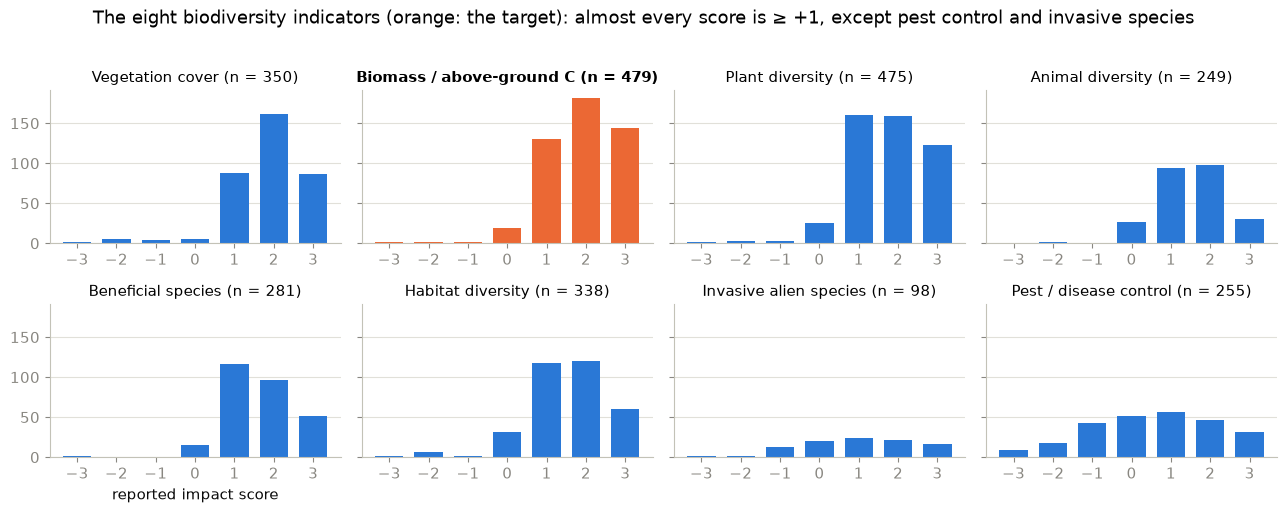

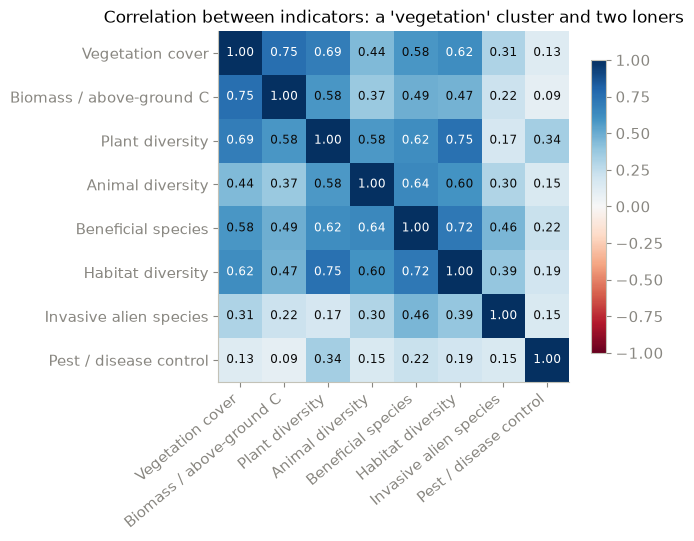

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharey=True)
for ax, b in zip(axes.ravel(), BIO):
    counts = bio_all[b].round().value_counts().reindex(range(-3, 4), fill_value=0)
    ax.bar(counts.index, counts.values, color=C_ORANGE if b == TARGET else C_BLUE, width=0.72)
    ax.set_title(f"{PRETTY[b]} (n = {int(bio_all[b].notna().sum())})", fontsize=10.5, fontweight="bold" if b == TARGET else "normal")
    ax.set_xticks(range(-3, 4)); ax.grid(True, axis="y")
axes[1, 0].set_xlabel("reported impact score")
fig.suptitle("The eight biodiversity indicators (orange: the target): almost every score is ≥ +1, except pest control and invasive species", y=1.02)
plt.tight_layout(); plt.show()

corr = bio_all[BIO].corr()
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(corr.values, cmap="RdBu", vmin=-1, vmax=1)
labels = [PRETTY[b] for b in BIO]
ax.set_xticks(range(8), labels, rotation=40, ha="right"); ax.set_yticks(range(8), labels)
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8.5, color="white" if abs(corr.values[i, j]) > 0.6 else INK)
ax.set_title("Correlation between indicators: a 'vegetation' cluster and two loners"); fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

**Target:** The research question asks which technologies report a *high* rather than a *low* improvement, so the target is a cut between the two, and the median is the natural place for it. The label `bio_high` is 1 when a technology's biomass / above-ground C score sits above the median. The scores are whole numbers and the median is +2, a single step that holds 38 % of the records, so "above the median" means **the top rating +3 against +2 or less**: 144 high against 335 low, a 30 / 70 split. "At or above the median" would count +2 as high as well (68 / 32). We keep the strict rule. Section 7.2 reports the other split, and section 6.5 checks the binary target against the full seven-step scale.

**Imbalance:** AUC is the main metric, because it depends neither on a threshold nor on the class balance. For macro-F1 and balanced accuracy each model flags the top 30 % or so of its test fold by predicted probability (`scores_from` in section 3 states the rule). We do not use class weights: they would distort the predicted probabilities, and section 7.3 reads those directly.

Only 479 of the 895 technologies with a biodiversity score rate biomass, so every model below trains and tests on those 479. The eight indicator columns, with `NaN` where an indicator was not scored, are the extra targets of the multi-task network. Their mean is the alternative target of section 7.2.


## 3. Features and the country-grouped split

The inputs are the Module 2 fields of the research plan, one-hot or multi-hot encoded into 102 binary features. Missing answers become their own category. The **block** column groups the fields for the coefficient plot of section 4 and the permutation test of section 7.4.

| research-plan field (questionnaire section) | role in the plan | block | column |
|---|---|---|---|
| SLM group (3.5) | essential | practice | `slm_group`, multi-answer |
| SLM measures (3.6) | essential | practice | `measures`, multi-answer |
| Land degradation addressed (3.7) | essential | practice | `degradation`, multi-answer |
| Groundwater table (5.4) | essential | environment | `groundwater`, 4 depth levels, **new** |
| Availability of surface water (5.4) | essential | environment | `surfacewater`, 4 levels, **new** |
| Cost of establishment (4.4) | essential | cost | `establishment_cost`, USD quartile, **new** |
| Cost of maintenance (4.6) | essential | cost | `maintenance_cost`, USD quartile, **new** |
| Main purpose (3.1) | optional | practice | `main_purpose`, multi-answer |
| Current land use | optional | land use | `landuse`, multi-answer |
| Water supply | optional | environment | `watersupply` |
| Agro-climatic zone (5.1) | optional | environment | `agroclimatic_zone` |
| Slope (6.2) | optional | environment | `slope` |

Four optional fields of the plan (land use before the technology, tillage, prevent / reduce / restore, date of implementation) are still not in the cached table; section 8 lists them.

Some fields are **excluded on purpose**. Country and coordinates only group the folds, because as features they would let the model memorise regions. `compiler_id` would teach the model who filled in the form, which does not transfer to unseen countries. The other `imp_*` blocks come from the same form and the same rater, and cost-benefit and adoption are outcome-like. Ten environment and context fields the plan does not list (rainfall, altitude, landform, soil depth, soil texture, topsoil organic matter, market orientation, mechanisation, land size, wealth) are left out; section 7.2 shows what they do.

**Split:** Five folds, stratified on the label and grouped by country, fixed once and reused by every model. Inside each training fold, a further country-grouped 15 % serves as the validation set for early stopping. The test fold is never touched during training.


In [4]:
# the research plan's input fields, in the blocks of the table above
ENVIRONMENT = ["agroclimatic_zone", "slope", "watersupply", "groundwater", "surfacewater"]
COST = ["establishment_cost", "maintenance_cost"]
LAND_USE = ["landuse"]
PRACTICE = ["slm_group", "measures", "degradation", "main_purpose"]
NEW = ["groundwater", "surfacewater", *COST]           # the four fields from Dima's extraction
SINGLE, MULTI = ENVIRONMENT + COST, LAND_USE + PRACTICE
BLOCK_OF = {**{c: "environment" for c in ENVIRONMENT}, **{c: "cost" for c in COST},
            **{c: "land use" for c in LAND_USE}, **{c: "practice" for c in PRACTICE}}

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score

def tokens(series):
    return series.apply(lambda v: v.split("|") if isinstance(v, str) and v else ["MISSING"])

def encode_onehot(df, single=SINGLE, multi=MULTI):
    frames = []
    for col in single:
        enc = OneHotEncoder(sparse_output=False, dtype=np.float32)
        arr = enc.fit_transform(df[[col]].fillna("MISSING").astype(str))
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in enc.categories_[0]], index=df["technology_id"]))
    for col in multi:
        mlb = MultiLabelBinarizer()
        arr = mlb.fit_transform(tokens(df[col]).tolist()).astype(np.float32)
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in mlb.classes_], index=df["technology_id"]))
    return pd.concat(frames, axis=1)

X_df = encode_onehot(wocat).loc[data["technology_id"]]
X = X_df.to_numpy(dtype=np.float32)
FIELD_OF = {c: c.split("=")[0] for c in X_df.columns}
groups = data["country_name"].to_numpy()

FOLDS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y, groups))

def inner_split(train_idx, seed=SEED):
    tr, va = next(GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed).split(train_idx, groups=groups[train_idx]))
    return train_idx[tr], train_idx[va]

def scores_from(y_true, p, share_train):
    """AUC needs no threshold. Macro-F1 and balanced accuracy flag the top share_train of the fold by predicted probability
    (as many records as the training fold has 'high' ones): a quantile of the model's own predictions, so a model whose
    probabilities sit uniformly too high or too low is not punished twice. A constant prediction flags nothing."""
    yhat = (p > np.quantile(p, 1.0 - share_train)).astype(int)
    return {"AUC": roc_auc_score(y_true, p), "macro-F1": f1_score(y_true, yhat, average="macro"),
            "balanced acc.": balanced_accuracy_score(y_true, yhat)}

RESULTS = {}
def record(name, fold_scores, seconds):
    RESULTS[name] = {"folds": fold_scores, "seconds": seconds}
    df = pd.DataFrame(fold_scores)
    print(f"{name:40s} AUC {df['AUC'].mean():.3f} ± {df['AUC'].std():.3f}   macro-F1 {df['macro-F1'].mean():.3f} ± {df['macro-F1'].std():.3f}   ({seconds:4.0f} s)")

def summary_table():
    rows = []
    for name, r in RESULTS.items():
        df = pd.DataFrame(r["folds"])
        rows.append({"approach": name, "AUC": df["AUC"].mean(), "AUC sd": df["AUC"].std(), "macro-F1": df["macro-F1"].mean(),
                     "macro-F1 sd": df["macro-F1"].std(), "balanced acc.": df["balanced acc."].mean(), "seconds": r["seconds"]})
    return pd.DataFrame(rows).set_index("approach")

print(f"{X.shape[0]} technologies x {X.shape[1]} features; {len(set(groups))} countries")
print(pd.DataFrame([{"fold": k, "train": len(tr), "test": len(te), "test countries": len(set(groups[te])),
                     "share high (test)": round(y[te].mean(), 2)} for k, (tr, te) in enumerate(FOLDS)]).set_index("fold").to_string())

479 technologies x 102 features; 87 countries
      train  test  test countries  share high (test)
fold                                                
0       380    99              22               0.30
1       388    91              20               0.29
2       388    91              19               0.30
3       373   106               8               0.33
4       387    92              18               0.28


## 4. Yardstick: logistic regression

One classical model on the same folds. Logistic regression is the same model as a neural network with zero hidden layers, so the gap between it and the networks below measures exactly what hidden layers add: interactions between features. (A majority-class guess scores AUC 0.5 by construction, and a random forest of 500 trees came out level with logistic regression on the same folds, with the same features at the top. Neither is shown.)

The signed coefficients answer the research plan's question of how important the input features are. The cells after them check the direction of the top features, what the four new fields contribute, and one pattern behind the top features.


In [5]:
from sklearn.linear_model import LogisticRegression

make_logreg = lambda: LogisticRegression(C=0.3, max_iter=5000)

def cv_sklearn(make_model, X_, y_, folds):
    out = []
    for tr, te in folds:
        model = make_model().fit(X_[tr], y_[tr])
        out.append(scores_from(y_[te], model.predict_proba(X_[te])[:, 1], y_[tr].mean()))
    return out

def run_sklearn_cv(name, make_model):
    t0 = time.time()
    record(name, cv_sklearn(make_model, X, y, FOLDS), time.time() - t0)

NAME_0A = f"0a. Logistic regression ({X.shape[1]} fields)"
run_sklearn_cv(NAME_0A, make_logreg)


0a. Logistic regression (102 fields)     AUC 0.603 ± 0.060   macro-F1 0.587 ± 0.052   (   0 s)


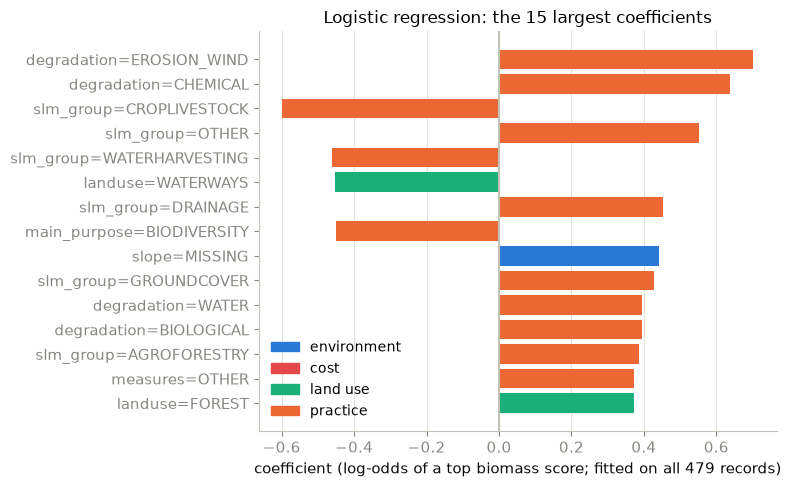

52 of 102 coefficients positive; blocks in the top 15: {'practice': 12, 'land use': 2, 'environment': 1}

                                 block  coefficient  prevalence  share high | present  share high | absent  difference
degradation=EROSION_WIND      practice        0.702       0.284                 0.426                0.251       0.176
degradation=CHEMICAL          practice        0.638       0.434                 0.389                0.232       0.157
slm_group=CROPLIVESTOCK       practice       -0.599       0.092                 0.159                0.315      -0.156
slm_group=OTHER               practice        0.553       0.065                 0.419                0.292       0.127
slm_group=WATERHARVESTING     practice       -0.461       0.067                 0.156                0.311      -0.155
landuse=WATERWAYS             land use       -0.452       0.040                 0.158                0.307      -0.149
slm_group=DRAINAGE            practice        0.452       0.0

In [6]:
logreg = make_logreg().fit(X, y)
coef = pd.Series(logreg.coef_[0], index=X_df.columns)
imp = coef.reindex(coef.abs().sort_values(ascending=False).index).head(15)   # the 15 largest coefficients, sign kept
present = {f: (X_df[f] == 1).to_numpy() for f in imp.index}
direction = pd.DataFrame({"block": [BLOCK_OF[FIELD_OF[f]] for f in imp.index],
                          "coefficient": imp.values,
                          "prevalence": [present[f].mean() for f in imp.index],
                          "share high | present": [y[present[f]].mean() for f in imp.index],
                          "share high | absent": [y[~present[f]].mean() for f in imp.index]}, index=imp.index)
direction["difference"] = direction["share high | present"] - direction["share high | absent"]

fig, ax = plt.subplots(figsize=(8, 5))
colours = {"environment": C_BLUE, "cost": C_RED, "land use": C_AQUA, "practice": C_ORANGE}
ax.barh(imp.index[::-1], imp.values[::-1], color=[colours[BLOCK_OF[FIELD_OF[c]]] for c in imp.index[::-1]])
ax.axvline(0, color=NEUTRAL)
ax.legend(handles=[Patch(color=v, label=k) for k, v in colours.items()], loc="best")
ax.set_xlabel("coefficient (log-odds of a top biomass score; fitted on all 479 records)")
ax.set_title("Logistic regression: the 15 largest coefficients"); ax.grid(True, axis="x")
plt.tight_layout(); plt.show()
print(f"{(coef > 0).sum()} of {len(coef)} coefficients positive; blocks in the top 15: {direction['block'].value_counts().to_dict()}\n")
print(direction.round(3).to_string())


In [7]:
# the four new fields level by level: share of 'high' (records in brackets), ordered levels first, then the missing answers
ORDER = {"groundwater": ["ONSURFACE", "LESS_5M", "5_50M", "50M_PLUS"], "surfacewater": ["EXCESS", "GOOD", "MEDIUM", "POOR"],
         "establishment_cost": COST_LEVELS, "maintenance_cost": COST_LEVELS}
for f in NEW:
    share = pd.Series(y).groupby(data[f].fillna("missing").to_numpy()).agg(["mean", "size"])
    print(f"{f:19s} " + " | ".join(f"{lvl} {share.loc[lvl, 'mean']:.2f} ({share.loc[lvl, 'size']})" for lvl in ORDER[f] + ["missing"] if lvl in share.index))


groundwater         ONSURFACE 0.38 (24) | LESS_5M 0.33 (80) | 5_50M 0.25 (224) | 50M_PLUS 0.32 (105) | missing 0.43 (46)
surfacewater        EXCESS 0.22 (18) | GOOD 0.30 (130) | MEDIUM 0.30 (172) | POOR 0.27 (125) | missing 0.47 (34)
establishment_cost  Q1 lowest 0.25 (80) | Q2 0.30 (86) | Q3 0.26 (81) | Q4 highest 0.29 (105) | missing 0.37 (127)
maintenance_cost    Q1 lowest 0.30 (73) | Q2 0.25 (63) | Q3 0.29 (76) | Q4 highest 0.27 (107) | missing 0.34 (160)


In [8]:
ticked = pd.DataFrame({f: tokens(data[f]).apply(lambda t: 0 if t == ["MISSING"] else len(t)) for f in PRACTICE})
by_count = {}
for f in PRACTICE:
    k = ticked[f].where(ticked[f] > 0).clip(upper=5)
    by_count[f] = pd.Series(y).groupby(k).agg(lambda s: f"{s.mean():.2f} ({len(s)})").reindex([1, 2, 3, 4, 5])
by_count = pd.DataFrame(by_count).T.set_axis(["1", "2", "3", "4", "5+"], axis=1)
print("share of 'high' by the number of answers ticked in each multi-answer practice field (records in brackets):")
print(by_count.to_string())
print()
print("Spearman correlation of the count with the label:", ", ".join(f"{f} {pd.Series(y).corr(ticked[f], method='spearman'):+.2f}" for f in PRACTICE))

share of 'high' by the number of answers ticked in each multi-answer practice field (records in brackets):
                       1           2           3          4          5+
slm_group     0.24 (131)  0.35 (145)  0.28 (174)   0.50 (6)         NaN
measures      0.20 (166)  0.35 (161)  0.30 (100)  0.47 (47)    0.67 (3)
degradation   0.17 (100)  0.23 (119)  0.36 (122)  0.38 (88)   0.47 (49)
main_purpose   0.42 (81)   0.32 (77)   0.18 (55)  0.34 (53)  0.27 (157)

Spearman correlation of the count with the label: slm_group +0.01, measures +0.16, degradation +0.21, main_purpose -0.03


In [9]:
# feature sets against each other, same model and folds: what is in the fields vs. how many answers are ticked
X_new_only = X_df.loc[:, [c for c in X_df.columns if FIELD_OF[c] in NEW]].to_numpy(dtype=np.float32)
X_without_new = X_df.loc[:, [c for c in X_df.columns if FIELD_OF[c] not in NEW]].to_numpy(dtype=np.float32)
X_counts = ticked[["degradation", "measures"]].to_numpy(dtype=np.float32)
count_rows = []
for feats, Xv in [("the four new fields only", X_new_only), ("the other plan fields", X_without_new), ("all plan fields (section 3)", X),
                  ("two counts only (degradation types, measures)", X_counts), ("all plan fields + two counts", np.hstack([X, X_counts]))]:
    auc = pd.DataFrame(cv_sklearn(make_logreg, Xv, y, FOLDS))["AUC"]
    count_rows.append({"features": feats, "columns": Xv.shape[1], "AUC": auc.mean(), "sd": auc.std()})
print(pd.DataFrame(count_rows).set_index("features").round(3).to_string())
print()
t0 = time.time()
record("0b. Logistic regression (two counts)", cv_sklearn(make_logreg, X_counts, y, FOLDS), time.time() - t0)


                                               columns    AUC     sd
features                                                            
the four new fields only                            20  0.488  0.074
the other plan fields                               82  0.629  0.035
all plan fields (section 3)                        102  0.603  0.060
two counts only (degradation types, measures)        2  0.636  0.066
all plan fields + two counts                       104  0.609  0.053

0b. Logistic regression (two counts)     AUC 0.636 ± 0.066   macro-F1 0.588 ± 0.061   (   0 s)


**Reading the coefficients:** None of the four new fields reaches the fifteen largest coefficients, and the environment block appears there only through a missing slope answer (9 records, to be ignored). The two largest are degradation types: technologies that address wind erosion report the top biomass score 43 % of the time against 25 % for the rest (coefficient +0.70), and chemical degradation adds 16 points (+0.64). The two clearest negatives are SLM groups, crop-livestock integration (16 % against 32 %, -0.60) and water harvesting (16 % against 31 %, -0.46), which also sit at the bottom of the what-if ranking in section 7.3. Ground cover (+0.43), drainage (+0.45, on 17 records), agroforestry (+0.39) and forest as the land use (+0.37) point up. The coefficients are fitted on all 479 records at once, so they describe the fit; section 7.4 asks what transfers to unseen countries.

**The four new fields carry no signal.** Across the depth of the groundwater table, the availability of surface water and the two cost quartiles the share of top scores stays between 0.22 and 0.38 without a trend: the most expensive quartile reports a +3 about as often as the cheapest. On their own the twenty new columns score AUC 0.49, chance. The one level that stands out is *missing*: technologies whose compiler left the water block or the cost table empty report a +3 in 34 to 47 % of cases. Adding the four fields to the other 82 costs 0.03 AUC (0.629 to 0.603), the price of twenty more columns on 479 rows.

**The count matters more than the type.** Three degradation types sit near the top of the list and all point upward, which makes the number of types ticked the obvious suspect. Of the technologies that address one degradation type, 17 % report a +3, against 47 % of those that address five or more (Spearman +0.21). For measures the share rises from 20 % at one measure to 47 % at four. The number of SLM groups or main purposes shows no such trend.

**Two integers match 102 fields.** A logistic regression on just the two counts reaches AUC 0.636, the full model 0.603, and both together 0.609. Nothing the individual answers say adds to what the number of answers says. A technology that tackles many problems at once may really build more biomass, but the count is also a trace of how thoroughly the compiler filled in the form, just as the *missing* levels above are. It is the rater effect Dima warned about, reaching the model through a feature this time rather than through the scores. The count model enters the results table of section 7.1 as yardstick 0b, and every later result has to be read against it.


## 5. Method 1: a regularised feed-forward network

A multilayer perceptron on the 102 one-hot features, built with the Module 2 training toolbox:

| technique | what it does here |
|---|---|
| He initialisation | keeps activations at a sane scale through the layers |
| ReLU | non-saturating, no vanishing gradient |
| Batch normalisation | normalises inside the network, allows a larger learning rate (`use_bias=False` before it) |
| Dropout + L2 | the two regularisers that matter most with 480 rows |
| Adam | adaptive per-weight learning rates |
| `ReduceLROnPlateau` | halves the learning rate when the validation loss stalls |
| Early stopping | stops when the validation loss stops improving, restores the best weights |

We first show the failure mode without regularisation, then the regularised network, then the network we keep against a wide and deep one. **The network is small on purpose:** one hidden layer of 16 units with a strong L2 penalty (1e-2), about 1 700 parameters for about 320 training rows. The comparison after the loss curves puts it against a 128-64 network with 22 000 parameters and shows that on this data the closer a network stays to logistic regression, the better it does. Every cross-validated network result is a mean over **5 folds and 3 seeds** (`run_keras_seeds`), because with about 380 training rows the random seed alone moves a network's AUC by several hundredths. One handicap to keep in mind: early stopping needs a validation set, so a network trains on about 323 of a fold's 380 rows and watches the other 57, while the yardstick of section 4 fits all 380.

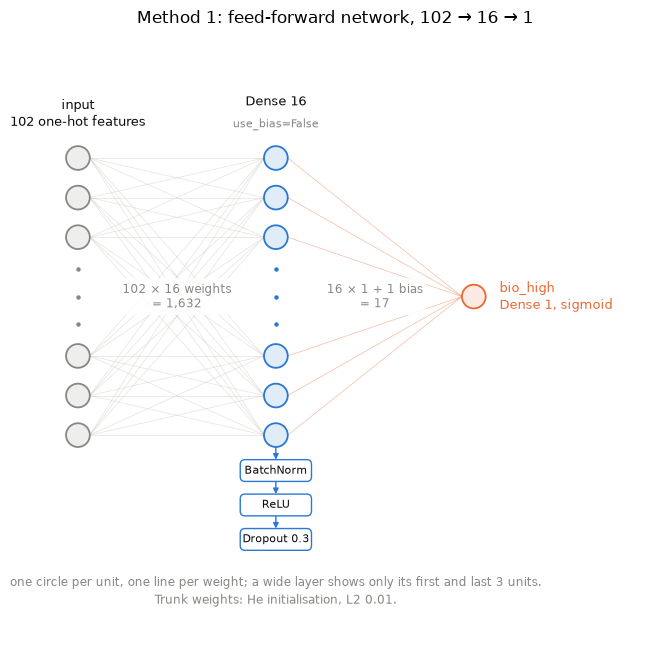

In [10]:
# The network, drawn: one column per layer, one circle per unit, one line per weight
from matplotlib.colors import to_rgb
from matplotlib.patches import FancyBboxPatch

def draw_network(ax, n_in, hidden, heads, l2=1e-2, show=3, r=0.3, dx=5.0):
    """One column per layer, one circle per unit, one line per weight. A layer wider than 2*show+2 units shows
    only its first and last `show` units and an ellipsis. heads: (units, activation, name, colour) per output layer."""
    tint = lambda c: tuple(1 - 0.14 * (1 - v) for v in to_rgb(c))

    def ys_of(n, centre):                     # y of the circles drawn for an n-unit layer centred at `centre`
        if n <= 2 * show + 2:
            return [centre + (n - 1) / 2 - i for i in range(n)]
        return [centre + show + 0.5 - i for i in range(show)] + [centre - 1.5 - i for i in range(show)]

    def column(x, n, colour, centre=0.0):
        ys = ys_of(n, centre)
        for y in ys:
            ax.add_patch(plt.Circle((x, y), r, facecolor=tint(colour), edgecolor=colour, linewidth=1.3, zorder=3))
        if len(ys) < n:
            ax.plot([x] * 3, [centre + 0.7, centre, centre - 0.7], "o", ms=2.2, color=colour, zorder=3)
        return ys

    def connect(x0, ys0, x1, ys1, colour, label, label_y):
        for a in ys0:
            for b in ys1:
                ax.plot([x0 + r, x1 - r], [a, b], color=colour, linewidth=0.5, alpha=0.45, zorder=1)
        ax.text((x0 + x1) / 2, label_y, label, ha="center", va="center", fontsize=8.5, color=INK_MUTED, zorder=4,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.9))

    def ops(x, y, colour, steps=("BatchNorm", "ReLU", "Dropout 0.3"), gap=0.32, h=0.55):
        for step in steps:                    # what every unit of the column then goes through, in this order
            ax.annotate("", xy=(x, y - gap), xytext=(x, y), zorder=2,
                        arrowprops=dict(arrowstyle="-|>", color=colour, lw=1.0, shrinkA=0, shrinkB=0, mutation_scale=8))
            ax.add_patch(FancyBboxPatch((x - 0.9, y - gap - h), 1.8, h, boxstyle="round,pad=0,rounding_size=0.12",
                                        facecolor="white", edgecolor=colour, linewidth=1.0, zorder=3))
            ax.text(x, y - gap - h / 2, step, ha="center", va="center", fontsize=7.8, color=INK, zorder=4)
            y -= gap + h

    x, ys, n = 0.0, column(0.0, n_in, INK_MUTED), n_in
    ax.text(0, max(ys) + r + 0.4, f"input\n{n_in} one-hot features", ha="center", va="bottom", fontsize=9.5, color=INK)
    for units in hidden:                      # the trunk: Dense -> BatchNorm -> ReLU -> Dropout per hidden layer
        ys_new = column(x + dx, units, C_BLUE)
        connect(x, ys, x + dx, ys_new, NEUTRAL, f"{n} × {units} weights\n= {n * units:,}", 0.0)
        ax.text(x + dx, max(ys_new) + r + 0.95, f"Dense {units}", ha="center", va="bottom", fontsize=9.5, color=INK)
        ax.text(x + dx, max(ys_new) + r + 0.4, "use_bias=False", ha="center", va="bottom", fontsize=8, color=INK_MUTED)
        ops(x + dx, min(ys_new) - r, C_BLUE)
        x, ys, n = x + dx, ys_new, units
    heights = [min(u, 2 * show + 2) for u, *_ in heads]
    top = (sum(heights) + 1.5 * (len(heads) - 1)) / 2
    for (units, activation, name, colour), h in zip(heads, heights):   # the head(s), fully connected to the last trunk layer
        centre = top - h / 2
        ys_h = column(x + dx, units, colour, centre)
        connect(x, ys, x + dx, ys_h, colour, f"{n} × {units} + {units} bias\n= {n * units + units:,}", centre / 2)
        ax.text(x + dx + r + 0.35, centre, f"{name}\nDense {units}, {activation}", ha="left", va="center", fontsize=9.5, color=colour)
        top -= h + 1.5
    ax.text((x + dx) / 2, -show - 4.0, f"one circle per unit, one line per weight; a wide layer shows only its first and last {show} units.\n"
            f"Trunk weights: He initialisation, L2 {l2:g}.", ha="center", va="top", fontsize=8.5, color=INK_MUTED, linespacing=1.5)
    ax.set_xlim(-1.5, x + dx + 4.5); ax.set_ylim(-show - 5.6, show + 3.7); ax.set_aspect("equal"); ax.axis("off")

fig, ax = plt.subplots(figsize=(8, 6.6))
draw_network(ax, X.shape[1], (16,), [(1, "sigmoid", "bio_high", C_ORANGE)])
ax.set_title(f"Method 1: feed-forward network, {X.shape[1]} → 16 → 1")
plt.tight_layout(); plt.show()


In [11]:
def dense_trunk(h, hidden=(16,), dropout=0.3, l2=1e-2, batchnorm=True, activation="relu", name="trunk"):
    reg = keras.regularizers.l2(l2) if l2 else None
    for i, units in enumerate(hidden):
        h = layers.Dense(units, kernel_initializer="he_normal", use_bias=not batchnorm, kernel_regularizer=reg)(h)
        if batchnorm:
            h = layers.BatchNormalization()(h)
        h = layers.Activation(activation, name=f"{name}_out" if i == len(hidden) - 1 else None)(h)
        if dropout:
            h = layers.Dropout(dropout)(h)
    return h

def build_mlp(hidden=(16,), dropout=0.3, l2=1e-2, batchnorm=True, activation="relu", lr=1e-3):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    out = layers.Dense(1, activation="sigmoid", name="bio_high")(dense_trunk(inp, hidden, dropout, l2, batchnorm, activation))
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="binary_crossentropy")
    return model

def callbacks(patience=15):
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)]

def run_keras_cv(build, Xany, extra_targets=None, epochs=150, batch_size=32, seed=SEED):
    """Grouped 5-fold CV for a Keras model whose (first) output is the bio_high sigmoid.
    build(train_idx) returns a compiled model. Returns (fold scores, fitted models)."""
    out, models = [], []
    for k, (tr, te) in enumerate(FOLDS):
        keras.utils.clear_session(); keras.utils.set_random_seed(seed + k)
        tr_in, va_in = inner_split(tr, seed + k)
        target = (lambda idx: y[idx]) if extra_targets is None else (lambda idx: {"bio_high": y[idx], **{n: t[idx] for n, t in extra_targets.items()}})
        model = build(tr_in)
        model.fit(Xany[tr_in], target(tr_in), validation_data=(Xany[va_in], target(va_in)),
                  epochs=epochs, batch_size=batch_size, callbacks=callbacks(), verbose=0)
        pred = model.predict(Xany[te], verbose=0)
        p = (pred["bio_high"] if isinstance(pred, dict) else pred).ravel()
        out.append(scores_from(y[te], p, y[tr].mean())); models.append(model)
    return out, models

SEEDS = (SEED, 7, 123)
def run_keras_seeds(build, Xany, extra_targets=None, name=None):
    """run_keras_cv once per seed. On ~380 training rows the seed alone moves a network's AUC by several
    hundredths, so every network result below is a mean over 5 folds x 3 seeds. Models come back seed by seed,
    fold by fold: models[i] was tested on (FOLDS * len(SEEDS))[i]."""
    t0, out, models = time.time(), [], []
    for s in SEEDS:
        fold_scores, fold_models = run_keras_cv(build, Xany, extra_targets, seed=s)
        out += fold_scores; models += fold_models
    if name:
        record(name, out, time.time() - t0)
    return out, models

build_mlp().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ onehot (InputLayer)             │ (None, 102)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ trunk_out (Activation)          │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bio_high (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,713 (6.69 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 32 (128.00 B)

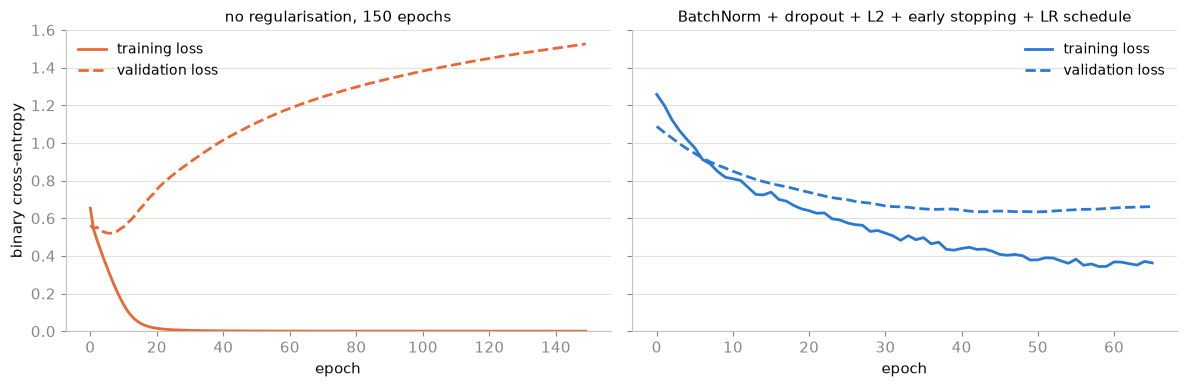

fold-0 test AUC: naive 0.657 (150 epochs)  |  regularised 0.602 (stopped after 66 epochs)


In [12]:
tr0, te0 = FOLDS[0]; tr_in0, va_in0 = inner_split(tr0)
keras.utils.set_random_seed(SEED)
naive = build_mlp(hidden=(256, 128), dropout=0.0, l2=0.0, batchnorm=False)
h_naive = naive.fit(X[tr_in0], y[tr_in0], validation_data=(X[va_in0], y[va_in0]), epochs=150, batch_size=32, verbose=0)
keras.utils.set_random_seed(SEED)
regular = build_mlp()
h_reg = regular.fit(X[tr_in0], y[tr_in0], validation_data=(X[va_in0], y[va_in0]), epochs=150, batch_size=32, callbacks=callbacks(), verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, hist, title, colour in [(axes[0], h_naive.history, "no regularisation, 150 epochs", C_ORANGE),
                                (axes[1], h_reg.history, "BatchNorm + dropout + L2 + early stopping + LR schedule", C_BLUE)]:
    ax.plot(hist["loss"], color=colour, linewidth=2, label="training loss")
    ax.plot(hist["val_loss"], color=colour, linewidth=2, linestyle="--", label="validation loss")
    ax.set_title(title, fontsize=11); ax.set_xlabel("epoch"); ax.legend(); ax.grid(True, axis="y")
axes[0].set_ylabel("binary cross-entropy"); axes[0].set_ylim(0, 1.6)
plt.tight_layout(); plt.show()
print(f"fold-0 test AUC: naive {roc_auc_score(y[te0], naive.predict(X[te0], verbose=0).ravel()):.3f} (150 epochs)  |  "
      f"regularised {roc_auc_score(y[te0], regular.predict(X[te0], verbose=0).ravel()):.3f} (stopped after {len(h_reg.history['loss'])} epochs)")

Left: the network memorises its ~320 training rows. The training loss falls to zero while the validation loss rises almost from the start. Right: with the toolbox the validation loss falls, flattens after about forty epochs, and early stopping ends training after about sixty-five. (Both curves on the right include the L2 penalty, which is why they start above the left-hand ones.) The single-fold test AUCs printed above come from one fold of 99 records and one seed. The gap between them is exactly the kind of noise the next cell averages away. What this cell shows is the shape of the two loss curves, not which network scores better.

**Size:** The next cell trains the small network and a wide, deep one (128-64, dropout 0.3, L2 1e-4) on the same grouped folds with three seeds. (Choosing between two candidates on the folds we report is slightly optimistic, by a fraction of an AUC point.)

In [13]:
SIZES = {"small (16), L2 1e-2": dict(hidden=(16,), dropout=0.3, l2=1e-2),
         "wide and deep (128-64), L2 1e-4": dict(hidden=(128, 64), dropout=0.3, l2=1e-4)}
sizes, small = [], None
for label, cfg in SIZES.items():
    t0 = time.time()
    fold_scores, _ = run_keras_seeds(lambda idx: build_mlp(**cfg), X)
    df = pd.DataFrame(fold_scores).assign(seed=np.repeat(SEEDS, len(FOLDS)))
    per_seed = df.groupby("seed", sort=False)["AUC"].mean()
    sizes.append({"config": label, "parameters": build_mlp(**cfg).count_params(), "AUC": df["AUC"].mean(),
                  **{f"AUC seed {s}": per_seed[s] for s in SEEDS}, "macro-F1": df["macro-F1"].mean(), "seconds": time.time() - t0})
    if small is None:
        small = (fold_scores, time.time() - t0)
print(pd.DataFrame(sizes).set_index("config").round(3).to_string())
record("1. Feed-forward net (16 units)", *small)


                                 parameters    AUC  AUC seed 42  AUC seed 7  AUC seed 123  macro-F1  seconds
config                                                                                                      
small (16), L2 1e-2                    1713  0.590        0.599       0.584         0.587     0.571  116.275
wide and deep (128-64), L2 1e-4       22081  0.554        0.556       0.555         0.551     0.545   71.832
1. Feed-forward net (16 units)           AUC 0.590 ± 0.057   macro-F1 0.571 ± 0.051   ( 116 s)


The small network scores AUC 0.590, the wide and deep one 0.554, and the three seeds agree on the order (0.584 to 0.599 against 0.551 to 0.556). Logistic regression, the network with no hidden layer, scores 0.603 and the two-count model 0.636. So the ladder runs the wrong way for depth: the closer a network stays to logistic regression, the better it does. On 479 rows of one-hot answers, hidden layers find no interactions worth their extra variance, and what the regularisation toolbox buys is training that is stable and stops by itself, not a higher score. We can say so only because the two logistic regressions are there to compare against.


## 6. Method 2: a multi-task network for all eight biodiversity indicators

The research plan names biomass as the main output and the other indicators of questionnaire section 6.1 as optional outputs, and section 2 showed they are correlated but not identical. So the network gets **two heads on one shared trunk**:

* `bio_high`, the same biomass high/low sigmoid classifier as method 1, trained with binary cross-entropy.
* `indicators`, eight linear outputs, one per indicator (biomass included), trained with a **masked mean squared error** that ignores the indicators a compiler did not score. The mask zeroes the error where the label is `NaN` and divides by the number of labels present.

The total loss is the weighted sum of the two, with weight 0.5 on the indicator head. The trunk has to serve nine targets at once, which regularises it, and the indicator head gives a prediction per indicator for every technology. That is the basis of the skill plot below. The trunk stays the wide and deep network of section 5 (128-64, dropout 0.3, L2 1e-4), since nine targets give it more to learn than one: with the 16-unit trunk the classification head scores AUC 0.565 against 0.575, inside the seed spread, with the same skill plot (not shown).

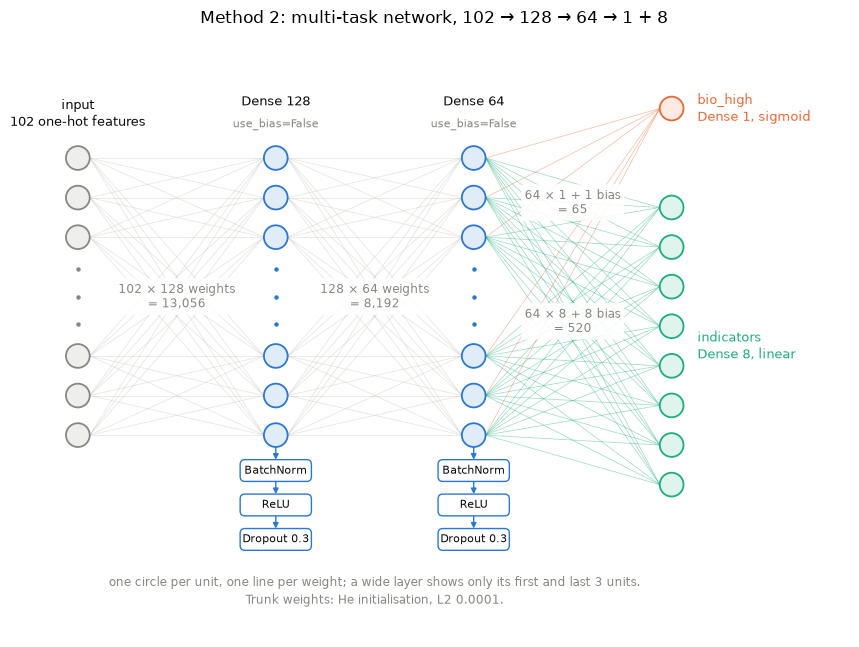

In [14]:
fig, ax = plt.subplots(figsize=(10, 6.6))
draw_network(ax, X.shape[1], (128, 64), [(1, "sigmoid", "bio_high", C_ORANGE), (len(BIO), "linear", "indicators", C_AQUA)], l2=1e-4)
ax.set_title(f"Method 2: multi-task network, {X.shape[1]} → 128 → 64 → 1 + {len(BIO)}")
plt.tight_layout(); plt.show()


In [15]:
def masked_mse(y_true, y_pred):
    mask = keras.ops.logical_not(keras.ops.isnan(y_true))
    y_true = keras.ops.where(mask, y_true, keras.ops.zeros_like(y_true))
    m = keras.ops.cast(mask, y_pred.dtype)
    return keras.ops.sum(keras.ops.square(y_true - y_pred) * m) / keras.ops.maximum(keras.ops.sum(m), 1.0)

def build_multitask(indicator_bias=None, hidden=(128, 64), dropout=0.3, l2=1e-4, lr=1e-3, indicator_weight=0.5):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    h = dense_trunk(inp, hidden, dropout, l2)
    out_high = layers.Dense(1, activation="sigmoid", name="bio_high")(h)
    # start the indicator head at the training means: from zero, early stopping (which watches the combined loss) halts
    # after ~5 epochs, before the head has learned the means of 1.5-1.9, and the per-indicator skill comes out spuriously negative
    bias_init = keras.initializers.Constant(indicator_bias) if indicator_bias is not None else "zeros"
    out_ind = layers.Dense(len(BIO), name="indicators", bias_initializer=bias_init)(h)
    model = keras.Model(inp, {"bio_high": out_high, "indicators": out_ind})
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss={"bio_high": "binary_crossentropy", "indicators": masked_mse},
                  loss_weights={"bio_high": 1.0, "indicators": indicator_weight})
    return model

_, models_C = run_keras_seeds(lambda idx: build_multitask(indicator_bias=np.nanmean(Y_IND[idx], axis=0)),
                              X, extra_targets={"indicators": Y_IND}, name="2. Multi-task net (8 indicators + high/low)")

2. Multi-task net (8 indicators + high/low) AUC 0.575 ± 0.070   macro-F1 0.549 ± 0.047   (  97 s)


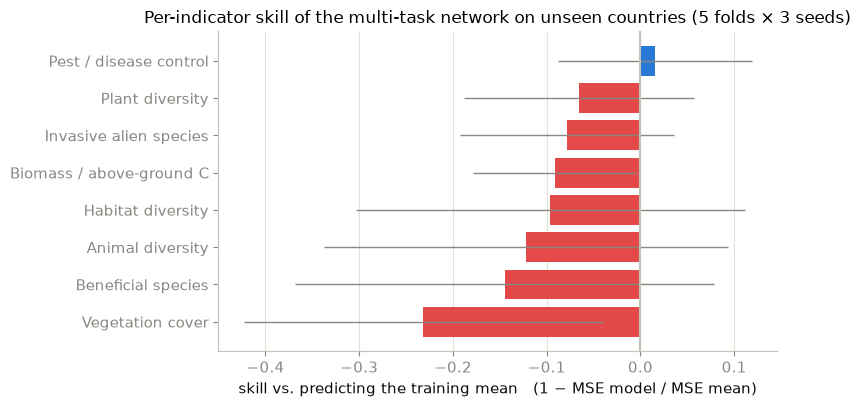

                             n  skill     sd
indicator                                   
Vegetation cover           600 -0.232  0.191
Beneficial species         525 -0.145  0.224
Animal diversity           471 -0.122  0.215
Habitat diversity          624 -0.096  0.207
Biomass / above-ground C  1437 -0.091  0.088
Invasive alien species     174 -0.078  0.114
Plant diversity            873 -0.066  0.123
Pest / disease control     396  0.015  0.103


In [16]:
rows = []
for model, (tr, te) in zip(models_C, FOLDS * len(SEEDS)):
    pred = model.predict(X[te], verbose=0)["indicators"]
    for j, b in enumerate(BIO):
        m = ~np.isnan(Y_IND[te, j])
        if m.sum() < 5:
            continue
        mse_model = np.mean((Y_IND[te, j][m] - pred[m, j]) ** 2)
        mse_mean = np.mean((Y_IND[te, j][m] - np.nanmean(Y_IND[tr, j])) ** 2)
        rows.append({"indicator": PRETTY[b], "n": int(m.sum()), "skill": 1 - mse_model / mse_mean})
skill = pd.DataFrame(rows).groupby("indicator").agg(n=("n", "sum"), skill=("skill", "mean"), sd=("skill", "std")).sort_values("skill")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(skill.index, skill["skill"], xerr=skill["sd"], color=[C_BLUE if s >= 0 else C_RED for s in skill["skill"]], error_kw=dict(ecolor=INK_MUTED, lw=1))
ax.axvline(0, color=NEUTRAL); ax.set_xlabel("skill vs. predicting the training mean   (1 − MSE model / MSE mean)")
ax.set_title("Per-indicator skill of the multi-task network on unseen countries (5 folds × 3 seeds)"); ax.grid(True, axis="x")
plt.tight_layout(); plt.show()
print(skill.round(3).to_string())

**Reading the skill plot:** Every bar sits between -0.23 and +0.02. On unseen countries the network predicts each biodiversity number *no better than that indicator's training mean*, biomass included (-0.09), even though the classification head finds some signal in the same data. The questionnaire fields do not carry the information, not even for the strongly inter-correlated vegetation cluster. This is a result, not a failure of the method: it is the per-indicator version of Dima's warning, and it tells us to read the what-if of section 7.3 as the model's *tendencies* rather than as predictions. On the shared `bio_high` head the multi-task network is level with method 1: AUC 0.575 against 0.590, a difference inside the seed-to-seed spread.


### 6.5 Does the median split throw information away?

Everything above predicts one bit: is the biomass score the top rating or not. The questionnaire offers seven steps, and section 7.2 shows that the headline depends on where the cut falls. If the binary target were a lossy shortcut, a model that sees the whole scale should beat it. So: the same folds, features and records, with the raw -3 to +3 rating as the target. Three models: a **floor** that always answers the training median (+2), **ridge regression** on the rating as a plain number, and an **ordinal cumulative-link logit**, six logistic models `P(rating >= k)` summed into an expected rating `E[y] = -3 + Σ_k P(y >= k)`. The ordinal model contains the rest of the notebook: its top threshold `P(rating >= +3)` *is* `bio_high`. Spearman ρ is the rank-based counterpart of AUC, MAE is read against the floor, `skill` = 1 - MSE model / MSE mean is the measure of section 6, and the last column scores the same continuous prediction against the binary target of section 7.1, which is where the two framings meet.


In [17]:
# --- the raw -3...+3 rating as the target, on the folds and features of section 3 ---------------
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge

y_raw = data[TARGET].to_numpy(dtype=np.float64)   # the rating itself, not the median split
THRESHOLDS = np.arange(-2, 4)                     # P(y >= k) for every level above the minimum

def reg_scores(te, pred, tr):
    """Ordinal metrics on one test fold. The AUC column scores this same continuous prediction
    against the binary target of section 7.1, so it is directly comparable to that table."""
    resid, base = y_raw[te] - pred, y_raw[te] - y_raw[tr].mean()
    return {"Spearman": pd.Series(y_raw[te]).corr(pd.Series(pred), method="spearman") if pred.std() > 0 else np.nan,
            "MAE": np.abs(resid).mean(),
            "skill": 1 - np.mean(resid ** 2) / np.mean(base ** 2),
            "AUC (binary target)": roc_auc_score(y[te], pred)}

def fit_threshold(X_tr, y_tr):
    """One cumulative threshold. A fold in which the level never occurs gets a constant probability
    (only 4 of 479 records sit below 0, so the bottom thresholds are near-degenerate by construction)."""
    if y_tr.min() == y_tr.max():
        return lambda X_te: np.full(len(X_te), float(y_tr.mean()))
    model = make_logreg().fit(X_tr, y_tr)
    return lambda X_te: model.predict_proba(X_te)[:, 1]

def ordinal_predict(tr, te):
    """E[rating] = lowest level + sum_k P(rating >= k)."""
    p = [fit_threshold(X[tr], (y_raw[tr] >= k).astype(int))(X[te]) for k in THRESHOLDS]
    return THRESHOLDS[0] - 1 + np.sum(p, axis=0)

ORDINAL = {}
def record_reg(name, fold_scores, seconds):
    ORDINAL[name] = {"folds": fold_scores, "seconds": seconds}
    df = pd.DataFrame(fold_scores)
    spearman = "    –  " if df["Spearman"].isna().all() else f"{df['Spearman'].mean():+.3f}"   # a constant prediction has no rank
    print(f"{name:34s} Spearman {spearman}   MAE {df['MAE'].mean():.3f}   "
          f"skill {df['skill'].mean():+.3f}   AUC {df['AUC (binary target)'].mean():.3f}   ({seconds:4.0f} s)")

def cv_predictor(predict):
    return [reg_scores(te, predict(tr, te), tr) for tr, te in FOLDS]

for name, predict in [("0. Always the training median", lambda tr, te: DummyRegressor(strategy="median").fit(X[tr], y_raw[tr]).predict(X[te])),
                      ("1. Ridge regression on the rating", lambda tr, te: Ridge(alpha=10.0).fit(X[tr], y_raw[tr]).predict(X[te])),
                      ("2. Ordinal cumulative-link logit", ordinal_predict)]:
    t0 = time.time()
    record_reg(name, cv_predictor(predict), time.time() - t0)

ordinal_table = pd.DataFrame({k: pd.DataFrame(r["folds"]).mean() for k, r in ORDINAL.items()}).T
ordinal_table["seconds"] = [r["seconds"] for r in ORDINAL.values()]
print()
print(ordinal_table.round(3).to_string(na_rep="–"))
print(f"\nthe three comparisons: skill against 0.000  |  MAE against the floor row "
      f"({ordinal_table.loc['0. Always the training median', 'MAE']:.3f})  |  AUC against logistic "
      f"regression on the median split ({summary_table().loc[NAME_0A, 'AUC']:.3f}, section 7.1)")


0. Always the training median      Spearman     –     MAE 0.684   skill -0.007   AUC 0.500   (   0 s)
1. Ridge regression on the rating  Spearman +0.173   MAE 0.770   skill -0.068   AUC 0.575   (   0 s)


2. Ordinal cumulative-link logit   Spearman +0.200   MAE 0.742   skill +0.003   AUC 0.603   (   0 s)

                                   Spearman    MAE  skill  AUC (binary target)  seconds
0. Always the training median             –  0.684 -0.007                0.500    0.027
1. Ridge regression on the rating     0.173  0.770 -0.068                0.575    0.054
2. Ordinal cumulative-link logit      0.200  0.742  0.003                0.603    0.211

the three comparisons: skill against 0.000  |  MAE against the floor row (0.684)  |  AUC against logistic regression on the median split (0.603, section 7.1)


**The median split throws nothing away.** Handed the whole scale, the ordinal model reaches AUC 0.603 on the binary target, the same 0.603 as logistic regression in section 7.1, which was built for that exact question. Its skill of +0.003 (Spearman +0.20) says that the questionnaire locates a technology on the seven-step scale no better than the training mean does. Ridge does worse than the floor on MAE, because 38 % of the records sit exactly on +2 and a model that spreads its predictions pays for every step it moves; what the ordinal model gains over ridge is what respecting the order of the scale buys. The binary result was never about the *median* but about +3 against the rest, the one boundary the questionnaire can see, and a model handed all seven steps finds its way back to it. The what-if in 7.3 therefore stays a probability of the top rating.


## 7. Results: which methods go with the largest reported biomass gains?

### 7.1 All models on the same folds


In [18]:
table = summary_table()
print(table.round(3).to_string())


                                               AUC  AUC sd  macro-F1  macro-F1 sd  balanced acc.  seconds
approach                                                                                                 
0a. Logistic regression (102 fields)         0.603   0.060     0.587        0.052          0.588    0.052
0b. Logistic regression (two counts)         0.636   0.066     0.588        0.061          0.589    0.037
1. Feed-forward net (16 units)               0.590   0.057     0.571        0.051          0.571  116.275
2. Multi-task net (8 indicators + high/low)  0.575   0.070     0.549        0.047          0.549   96.534


Logistic regression on the 102 fields (AUC 0.603) and on the two counts (0.636) are within one fold-to-fold standard deviation of each other, and section 6.5's ordinal model joins them at 0.603 on this same binary target. Both networks sit 0.05 to 0.06 AUC below the count model; their standard deviations pool seed variance with fold variance, 15 values against 5. With the quantile threshold the macro-F1 column tells the same story, even though the networks' probabilities run high (the multi-task ensemble predicts P(high) = 0.36 on average for a class share of 0.30, section 7.3). Every model is above chance, but not by much: AUC 0.6 means that out of a random pair of one +3 record and one lower record, the model ranks the +3 higher 60 % of the time.

### 7.2 Sensitivity: does following the research plan matter?

Logistic regression on six variants of the problem: the biomass target with and without the four new fields, split both ways, with the ten extra fields, and the mean of all eight indicators (895 records) with both feature sets. Each variant gets its own stratified, country-grouped folds. The first row is the main analysis and repeats 0a.


In [19]:
EXTRA = ["rainfall", "altitude", "landform", "soil_depth", "soil_texture", "topsoil_organic",   # fields the research plan does not list
         "market_orientation", "mechanisation", "land_size", "wealth"]
X_research = encode_onehot(wocat)
FEATURES = {"plan fields": X_research,
            "plan fields without the 4 new": X_research.loc[:, [c for c in X_research.columns if FIELD_OF[c] not in NEW]],
            "plan fields + 10 extra": encode_onehot(wocat, SINGLE + EXTRA, MULTI)}
biomass, mean8 = bio_all[TARGET], bio_all["bio_mean"]
VARIANTS = [  # (target, split, features, label, rows)
    ("biomass", "> median (+3 vs rest)", "plan fields", biomass > MEDIAN, biomass.notna()),
    ("biomass", "> median (+3 vs rest)", "plan fields without the 4 new", biomass > MEDIAN, biomass.notna()),
    ("biomass", ">= median (+2, +3 vs rest)", "plan fields", biomass >= MEDIAN, biomass.notna()),
    ("biomass", "> median (+3 vs rest)", "plan fields + 10 extra", biomass > MEDIAN, biomass.notna()),
    ("8-indicator mean", "> its median", "plan fields", mean8 > mean8.median(), mean8.notna()),
    ("8-indicator mean", "> its median", "plan fields + 10 extra", mean8 > mean8.median(), mean8.notna()),
]
rows = []
for target, split, feats, label, keep in VARIANTS:
    ids = bio_all.loc[keep, "technology_id"]
    Xv = FEATURES[feats].loc[ids].to_numpy(dtype=np.float32)
    yv, gv = label[keep].astype(int).to_numpy(), bio_all.loc[keep, "country_name"].to_numpy()
    folds_v = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(Xv, yv, gv))
    row = {"target": target, "split": split, "features": f"{feats} ({Xv.shape[1]})", "records": len(yv), "share high": yv.mean()}
    auc = pd.DataFrame(cv_sklearn(make_logreg, Xv, yv, folds_v))["AUC"]
    row["AUC"], row["sd"] = auc.mean(), auc.std()
    rows.append(row)
sensitivity = pd.DataFrame(rows)
print(sensitivity.round(3).to_string(index=False))


          target                      split                           features  records  share high   AUC    sd
         biomass      > median (+3 vs rest)                  plan fields (102)      479       0.301 0.603 0.060
         biomass      > median (+3 vs rest) plan fields without the 4 new (82)      479       0.301 0.629 0.035
         biomass >= median (+2, +3 vs rest)                  plan fields (102)      479       0.681 0.568 0.036
         biomass      > median (+3 vs rest)       plan fields + 10 extra (168)      479       0.301 0.574 0.034
8-indicator mean               > its median                  plan fields (102)      895       0.489 0.561 0.039
8-indicator mean               > its median       plan fields + 10 extra (168)      895       0.489 0.521 0.044


Three things follow.

* **Biomass is the more predictable target.** With the same fields it reaches AUC 0.60 against 0.56 for the 8-indicator mean, on half the records. Averaging eight indicators mixes scores the form asks about for very different reasons, such as pest control and invasive species, and dilutes the one WOCAT cares about most.
* **More fields hurt.** The four new plan fields cost 0.03 AUC and the ten extra fields another 0.03 to 0.04: more one-hot columns for the same number of rows means more room to fit noise, and none of these fields carries a signal of its own.
* **The split matters.** Moving the cut one step down (+2 and +3 against +1 or less, 68 / 32) drops the AUC to 0.57. The fields separate the top rating from the rest better than they separate modest from good ratings. We keep the strict split because it is the literal reading of "above the median", but it is also the easier one, which is why the other split is reported.

### 7.3 Raw ranking vs. environment-adjusted what-if

The raw ranking mixes what a method does with *where* it is used: forest technologies sit in humid zones, water harvesting in arid ones. The multi-task network separates the two with a counterfactual. If every one of the 479 technologies had used method g, in its own climate, slope, water, costs and land use, what would the network expect? We switch every technology's SLM-group indicators to *only* g, leave everything else untouched, and predict **out of fold**: each record is scored only by the three multi-task models that did not train on it, one per seed, and the 479 scores are averaged. Grey is the raw share of +3 biomass scores among technologies listing the group, blue the what-if probability. The cell after the plot repeats the what-if for the agro-climatic zone with practice and land use held fixed.


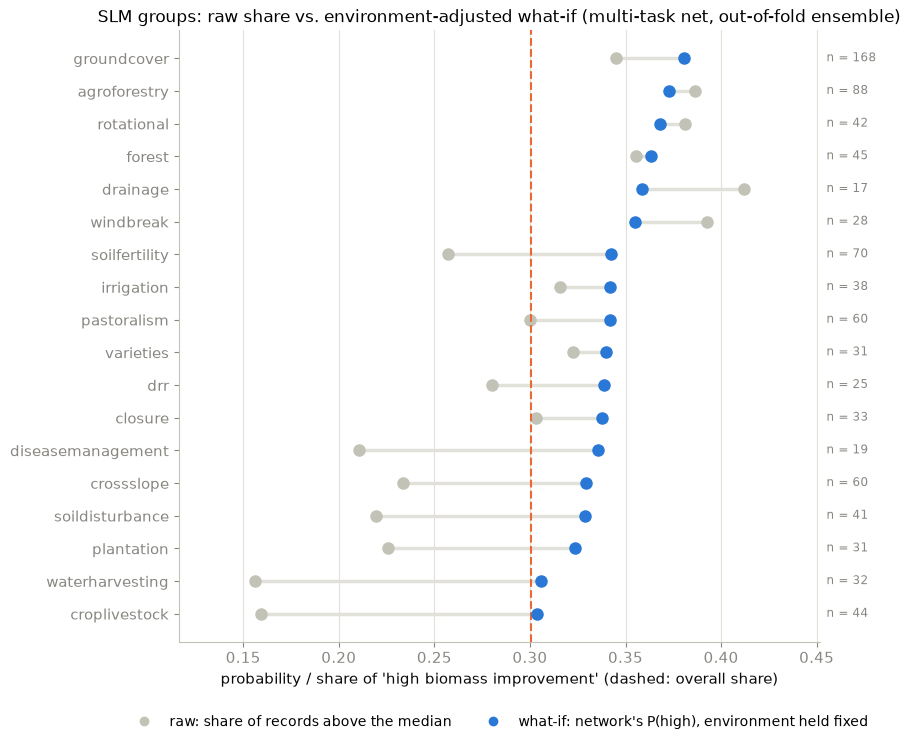

out-of-fold mean P(high) on the records as they are: 0.357; share of high records: 0.301

                     n  mean rating  raw share high  adjusted P(high)
GROUNDCOVER        168        2.030           0.345             0.381
AGROFORESTRY        88        2.091           0.386             0.373
ROTATIONAL          42        2.095           0.381             0.368
FOREST              45        2.044           0.356             0.363
DRAINAGE            17        2.118           0.412             0.359
WINDBREAK           28        2.036           0.393             0.355
SOILFERTILITY       70        1.871           0.257             0.343
PASTORALISM         60        1.817           0.300             0.342
IRRIGATION          38        1.895           0.316             0.342
VARIETIES           31        1.742           0.323             0.340
DRR                 25        1.760           0.280             0.339
CLOSURE             33        2.121           0.303             0.337


In [20]:
long = data[["bio_high", TARGET]].assign(group=tokens(data["slm_group"])).explode("group")
share_high = long.groupby("group")["bio_high"].mean()
n_group = long.groupby("group").size()
GROUPS_SHOWN = [g for g in n_group.index if n_group[g] >= 15 and g not in ("MISSING", "OTHER")]
SLM_COL = {c.split("=")[1]: j for j, c in enumerate(X_df.columns) if c.startswith("slm_group=")}

MODEL_FOLDS = list(zip(models_C, FOLDS * len(SEEDS)))   # models_C[i] was tested on (FOLDS * len(SEEDS))[i]

def oof_predict(Xany, model_folds=MODEL_FOLDS):
    """Out-of-fold ensemble: every record is predicted only by the models that did not train on it (one per seed),
    and the seeds are averaged. Returns P(high) per record."""
    p_high = np.zeros((len(SEEDS), len(Xany)))
    for i, (m, (_, te)) in enumerate(model_folds):
        p_high[i // len(FOLDS), te] = m.predict(Xany[te], verbose=0)["bio_high"].ravel()
    return p_high.mean(axis=0)

def what_if(category):
    Xc = X.copy(); Xc[:, list(SLM_COL.values())] = 0.0; Xc[:, SLM_COL[category]] = 1.0
    return oof_predict(Xc).mean()

P_OOF = oof_predict(X)   # the records as they are, scored out of fold
adjusted = pd.DataFrame({"adjusted P(high)": {g: what_if(g) for g in GROUPS_SHOWN}})
adjusted["raw share high"] = share_high.reindex(adjusted.index); adjusted["n"] = n_group.reindex(adjusted.index)
adjusted["mean rating"] = long.groupby("group")[TARGET].mean().reindex(adjusted.index)
adjusted = adjusted.sort_values("adjusted P(high)")

fig, ax = plt.subplots(figsize=(9, 0.32 * len(adjusted) + 1.8))
for i, (g, r) in enumerate(adjusted.iterrows()):
    ax.plot([r["raw share high"], r["adjusted P(high)"]], [i, i], color=GRID, linewidth=2.5, zorder=1)
    ax.plot(r["raw share high"], i, "o", color=NEUTRAL, markersize=8, zorder=2)
    ax.plot(r["adjusted P(high)"], i, "o", color=C_BLUE, markersize=8, zorder=3)
    ax.text(1.01, i, f"n = {int(r['n'])}", va="center", fontsize=8.5, color=INK_MUTED, transform=ax.get_yaxis_transform())
ax.plot([], [], "o", color=NEUTRAL, label="raw: share of records above the median")
ax.plot([], [], "o", color=C_BLUE, label="what-if: network's P(high), environment held fixed")
ax.axvline(y.mean(), color=C_ORANGE, linestyle="--", linewidth=1.5)
values = adjusted[["raw share high", "adjusted P(high)"]].to_numpy()
ax.set_yticks(range(len(adjusted)), [g.lower() for g in adjusted.index]); ax.set_xlim(values.min() - 0.04, values.max() + 0.04)
ax.set_xlabel("probability / share of 'high biomass improvement' (dashed: overall share)")
ax.set_title("SLM groups: raw share vs. environment-adjusted what-if (multi-task net, out-of-fold ensemble)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2); ax.grid(True, axis="x")
plt.tight_layout(); plt.show()
print(f"out-of-fold mean P(high) on the records as they are: {P_OOF.mean():.3f}; share of high records: {y.mean():.3f}\n")
print(adjusted[["n", "mean rating", "raw share high", "adjusted P(high)"]].round(3).sort_values("adjusted P(high)", ascending=False).to_string())

In [21]:
# the environment counterpart: switch every record's agro-climatic zone, practice and land use held fixed
ZONE_COL = {c.split("=")[1]: j for j, c in enumerate(X_df.columns) if c.startswith("agroclimatic_zone=")}
def what_if_zone(zone):
    Xz = X.copy(); Xz[:, list(ZONE_COL.values())] = 0.0; Xz[:, ZONE_COL[zone]] = 1.0
    return float(oof_predict(Xz).mean())

zone_whatif = pd.Series({z: what_if_zone(z) for z in ZONE_COL if z != "MISSING"})
raw_by_zone = pd.Series(y, index=data.index).groupby(data["agroclimatic_zone"]).agg(["size", "mean"])
print("agro-climatic zone: raw share of top biomass scores, and the what-if P(high) with practice and land use held fixed")
print(pd.DataFrame({"n": raw_by_zone["size"], "raw share high": raw_by_zone["mean"].round(3), "what-if P(high)": zone_whatif.round(3)})
      .dropna().sort_values("raw share high", ascending=False).to_string())
slm_spread = adjusted["adjusted P(high)"].max() - adjusted["adjusted P(high)"].min()
print(f"\nwhat-if spread: SLM group {slm_spread:.3f} over {len(adjusted)} groups | zone {zone_whatif.max() - zone_whatif.min():.3f} over {len(zone_whatif)} zones")


agro-climatic zone: raw share of top biomass scores, and the what-if P(high) with practice and land use held fixed
            n  raw share high  what-if P(high)
ARID       49           0.449            0.386
SEMIARID  187           0.342            0.377
HUMID      48           0.229            0.352
SUBHUMID  188           0.229            0.331

what-if spread: SLM group 0.077 over 18 groups | zone 0.055 over 4 zones


Arid sites report a top biomass score in 45 % of records, semi-arid in 34 %, humid and sub-humid in 23 %. The what-if, which hands every record a different zone while keeping its practice and land use, keeps that order at 0.39, 0.38, 0.35 and 0.33. The zone spread (0.06) is narrower than the SLM-group spread (0.08), but four categories have less room to spread than eighteen, and section 7.4 shows that the network barely uses either block, which pushes both what-ifs towards the base rate. The raw shares are the part that stands on its own.


### 7.4 Which feature blocks does the network actually use?

Permutation importance on the test folds. We shuffle one block of columns at a time, all columns of a block together so that multi-hot rows stay valid, and measure the AUC each of the 15 multi-task models loses on its own test fold.

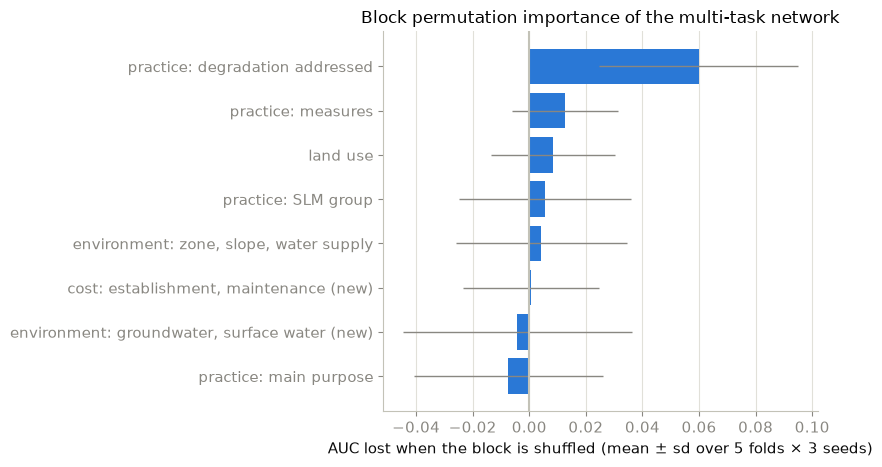

                                                mean    std
block                                                      
practice: main purpose                        -0.007  0.033
environment: groundwater, surface water (new) -0.004  0.040
cost: establishment, maintenance (new)         0.001  0.024
environment: zone, slope, water supply         0.004  0.030
practice: SLM group                            0.006  0.030
land use                                       0.008  0.022
practice: measures                             0.013  0.019
practice: degradation addressed                0.060  0.035


In [22]:
BLOCKS = {"environment: zone, slope, water supply": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in ("agroclimatic_zone", "slope", "watersupply")],
          "environment: groundwater, surface water (new)": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in ("groundwater", "surfacewater")],
          "cost: establishment, maintenance (new)": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in COST],
          "land use": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in LAND_USE],
          "practice: SLM group": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "slm_group"],
          "practice: measures": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "measures"],
          "practice: degradation addressed": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "degradation"],
          "practice: main purpose": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "main_purpose"]}
rng = np.random.default_rng(SEED); rows = []
for model, (tr, te) in zip(models_C, FOLDS * len(SEEDS)):
    base = roc_auc_score(y[te], model.predict(X[te], verbose=0)["bio_high"].ravel())
    for name, cols in BLOCKS.items():
        drops = []
        for _ in range(5):
            Xp = X[te].copy(); Xp[:, cols] = Xp[rng.permutation(len(te))][:, cols]
            drops.append(base - roc_auc_score(y[te], model.predict(Xp, verbose=0)["bio_high"].ravel()))
        rows.append({"block": name, "AUC drop": np.mean(drops)})
block_imp = pd.DataFrame(rows).groupby("block")["AUC drop"].agg(["mean", "std"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(block_imp.index, block_imp["mean"], xerr=block_imp["std"], color=C_BLUE, error_kw=dict(ecolor=INK_MUTED, lw=1))
ax.axvline(0, color=NEUTRAL); ax.set_xlabel("AUC lost when the block is shuffled (mean ± sd over 5 folds × 3 seeds)")
ax.set_title("Block permutation importance of the multi-task network"); ax.grid(True, axis="x")
plt.tight_layout(); plt.show()
print(block_imp.round(3).to_string())

### 7.5 Synthesis: the answer to the research question

* **How much is ticked predicts more than what is ticked.** Two integers, the number of degradation types and the number of measures a technology addresses, reach AUC 0.636 on unseen countries. All 102 questionnaire fields of the research plan reach 0.603 (section 4). The permutation test agrees from the network's side: shuffling the degradation block costs the multi-task network 0.06 (± 0.04) AUC and the measures block 0.01, while every other block, the four new fields included, costs nothing measurable (section 7.4). The strongest predictor of a reported top biomass score is how comprehensively a technology is described, which is as much a trace of the compiler as of the land.
* **The four newly added essential inputs change nothing.** Groundwater table, surface water and the two costs score at chance on their own (AUC 0.49), show no trend across their levels, and cost 0.03 AUC when added to the other fields. The only thing in them that moves the label is whether they were answered at all, the same compiler trace seen from the other side.
* **Ground cover, agroforestry, rotational systems, forest, drainage and windbreak form the top group** of the what-if, with raw shares of 0.35 to 0.41 and out-of-fold what-if probabilities of 0.36 to 0.38. **Water harvesting and crop-livestock integration trail** in every view: raw shares of 0.16, last places in the what-if, and mean ratings of +1.53 and +1.71 against +2.04 for forest and +2.09 for agroforestry.
* **Holding the environment fixed keeps the same six groups on top, reshuffled,** and compresses the range, from 0.16 to 0.41 down to 0.30 to 0.38. The network barely uses the SLM group (section 7.4), so switching it cannot move a probability far, and the level is off as well: mean P(high) 0.36 for a class share of 0.30. Read the order and the gaps, not the height of the blue dots.
* **The environment's signal is the agro-climatic zone.** Arid sites report a +3 in 45 % of records, semi-arid in 34 %, humid and sub-humid in 23 %, and the zone what-if keeps that order (0.39, 0.38, 0.35, 0.33). This is Module 1's "environment first" finding seen from the supervised side. The zone shows in the raw shares, the practice hardly shows at all.
* **The individual indicators are not predictable.** On unseen countries the multi-task network predicts none of the eight biodiversity indicators better than its training mean (skill -0.23 to +0.02, section 6), biomass included, while the same trunk's classification head reaches AUC 0.575. The questionnaire separates the top rating from the rest and locates very little else.


## 8. Conclusions and limitations

**What the numbers cannot say:** Every score is one person's opinion of their own project. There are no failures and no control plots, and compilers who documented many technologies rate systematically higher or lower. The what-if is the network's belief about *reported* impact in a counterfactual it never observed. It describes what the WOCAT community reports, not what works. The cost figures carry caveats of their own: they are totals in a unit the compiler chose, not per hectare, converted at the compiler's exchange rate and not adjusted for inflation, which is why they enter as quartiles.

**Module 2 methods used:** A feed-forward network designed, trained, regularised and sized with the D1 toolbox (method 1); a wide and deep network is the comparison, and on 479 rows the small one wins. A multi-output network built with the functional API and a custom masked loss (method 2, an extension of the course's multi-output and custom-loss examples). Grouped cross-validation repeated over three seeds, out-of-fold ensembling and permutation importance, for honest evaluation. On 479 rows of one-hot answers the networks find no interactions worth their extra variance, which the yardstick is there to detect. That is a result about the data, not a failure of the methods.

**Next steps:** With Dima's extraction the model has all seven essential inputs of the research plan, and the answer did not move, so the next gains lie with the compiler rather than with more fields. Compiler-grouped folds, the plan's "control for bias", would measure how much of the signal is who filled in the form, and a comparison of the 479 technologies that rate biomass with the 1 061 that do not would show whether those compilers are a particular kind. The four optional fields still missing (land use before the technology, tillage, prevent / reduce / restore, implementation date; API keys `landuse_change`, `agronomic_tillage`, `prevention`, `implementation_decades`) can be extracted the same way as the water and cost fields. A per-hectare cost, possible for the 190 of the 479 records that state an area basis, would be the honest version of the cost inputs.
